<div style="background-color:#0f172a; padding:22px; border-radius:12px; color:white;">

# 🚀 VelocIQ Project — EDA & Cleaning Pipeline

### 📌 Project Details

- **Project ID:** `VI-2024-001`
- **Client:** ZenKart Commerce Pvt. Ltd.
- **Analyst:** Jeet
- **Reviewed By:** Sourajit Tripathy
- **Script:** Step 3 — Full EDA & Cleaning Pipeline
- **Input File:** `zenkart_velociq_1M.csv`

---

## 📂 Outputs

- `zenkart_velociq_clean.csv`
- `zenkart_velociq_rfm.csv`
- `eda_plots/` *(8 PNG Charts)*

</div>PNG Charts)*======
"""

In [48]:
import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings, os
%matplotlib inline

In [3]:
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
os.makedirs("eda_plots", exist_ok=True)
 
print("="*60)
print("  PROJECT VelocIQ — EDA & CLEANING PIPELINE")
print("  Client : ZenKart Commerce Pvt. Ltd.")
print("  Analyst: Jeet  |  Reviewed by: Sourajit Tripathy")
print("="*60)

  PROJECT VelocIQ — EDA & CLEANING PIPELINE
  Client : ZenKart Commerce Pvt. Ltd.
  Analyst: Jeet  |  Reviewed by: Sourajit Tripathy


# PHASE 1 — LOAD & INSPECT


In [4]:
print("\n[PHASE 1] Loading data...")
df=pd.read_csv("zenkart_velociq_1M.csv")
df.head(3)


[PHASE 1] Loading data...


,order_id,customer_id,order_date,order_time,year,month,day_of_week,product_category,region,device_type,quantity,base_revenue_inr,discount_pct,final_revenue_inr,session_duration_mins,cart_abandon_flag,return_flag,payment_method
0,ZK0000000000,08BAE964-4,09-02-2023,06:19:44,2023,2,Thursday,Clothing,West,desktop,6,137.76,10,123.98,1.0,1,0,UPI
1,ZK0000000001,E0A80086-D,15-01-2024,03:52:52,2024,1,Monday,Electronics,West,desktop,6,49.00,0,49.00,6.8,0,0,Credit Card
2,ZK0000000002,C1ACF96E-4,03-10-2023,20:30:10,2023,10,Tuesday,Electronics,Central,mobile,1,353.50,5,335.82,11.1,0,0,UPI


In [5]:
print(f"  Shape            : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Memory usage     : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"  Date range       : {df['order_date'].min()} → {df['order_date'].max()}")
print(f"  Null values      : {df.isnull().sum().sum()}")
print(f"  Duplicate rows   : {df.duplicated().sum():,}")

  Shape            : 1,000,000 rows × 18 columns
  Memory usage     : 587.9 MB
  Date range       : 01-01-2023 → 31-12-2024
  Null values      : 0
  Duplicate rows   : 0


# PHASE 2 — CLEAN


In [5]:
print("\n[PHASE 2] CLEANING DATA...")


[PHASE 2] CLEANING DATA...


In [5]:
rows_before = len(df)
rows_before

1000000

In [6]:
# drop null values
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

In [7]:
# Fix the data types

df["order_date"] = pd.to_datetime(df["order_date"],format="%d-%m-%Y")
df["cart_abandnon_flag"] = df["cart_abandon_flag"].astype(int)
df["return_flag"] = df["return_flag"].astype(int)
df["discount_pct"]    = df["discount_pct"].astype(float)

In [8]:
df.dtypes

order_id                         object
customer_id                      object
order_date               datetime64[ns]
order_time                       object
year                              int64
month                             int64
day_of_week                      object
product_category                 object
region                           object
device_type                      object
quantity                          int64
base_revenue_inr                float64
discount_pct                    float64
final_revenue_inr               float64
session_duration_mins           float64
cart_abandon_flag                 int64
return_flag                       int32
payment_method                   object
cart_abandnon_flag                int32
dtype: object

In [9]:
# Remove revenue outliers using IQR
Q1 = df["final_revenue_inr"].quantile(0.25)
Q3 = df["final_revenue_inr"].quantile(0.75)

IQR = Q3-Q1

lower,upper = Q1-1.5*IQR , Q3+1.5*IQR
df = df[df["final_revenue_inr"].between(lower, upper)]

In [10]:
rows_after = len(df)
rows_after

884708

In [11]:
print(f"  Rows before clean : {rows_before:,}")
print(f"  Rows after clean  : {rows_after:,}")
print(f"  Rows removed      : {rows_before - rows_after:,} ({(rows_before-rows_after)/rows_before*100:.2f}%)")

  Rows before clean : 1,000,000
  Rows after clean  : 884,708
  Rows removed      : 115,292 (11.53%)


# PHASE 3 — FEATURE ENGINEERING

In [12]:
# Time features
df["month_name"] = df["order_date"].dt.strftime("%b")
df["quarter"]    = df["order_date"].dt.quarter.map({1:"Q1",2:"Q2",3:"Q3",4:"Q4"})
df["is_weekend"] = df["order_date"].dt.dayofweek.isin([5,6]).astype(int)
df["is_festive"] = df["month"].isin([10, 11]).astype(int)

In [13]:
# Customer-level aggregations

cust = df.groupby("customer_id").agg(
    total_orders   = ("order_id",           "count"),
    total_spend    = ("final_revenue_inr",  "sum"),
    avg_order_val  = ("final_revenue_inr",  "mean"),
    last_order     = ("order_date",         "max"),
    first_order    = ("order_date",         "min"),
).reset_index()
 
df = df.merge(cust, on="customer_id", how="left")
df["clv_proxy"]   = df["total_spend"]
df["aov"]         = df["avg_order_val"]
 
# Discount flag
df["high_discount"] = (df["discount_pct"] >= 20).astype(int)

In [14]:
df.head(4)

,order_id,customer_id,order_date,order_time,year,month,day_of_week,product_category,region,device_type,...,is_weekend,is_festive,total_orders,total_spend,avg_order_val,last_order,first_order,clv_proxy,aov,high_discount
0,ZK0000000000,08BAE964-4,2023-02-09,06:19:44,2023,2,Thursday,Clothing,West,desktop,...,0,0,3,221.98,73.993333,2024-06-17,2023-02-09,221.98,73.993333,0
1,ZK0000000001,E0A80086-D,2024-01-15,03:52:52,2024,1,Monday,Electronics,West,desktop,...,0,0,112,8153.38,72.798036,2024-12-24,2023-01-01,8153.38,72.798036,0
2,ZK0000000003,D14D86CF-A,2024-12-17,09:14:27,2024,12,Tuesday,Clothing,South,tablet,...,0,0,2,141.88,70.940000,2024-12-17,2024-03-19,141.88,70.940000,0
3,ZK0000000004,BA38397B-5,2023-08-01,11:18:57,2023,8,Tuesday,Electronics,Southeast,mobile,...,0,0,2,172.14,86.070000,2023-08-01,2023-03-10,172.14,86.070000,0


# PHASE 4 — RFM SEGMENTATION

In [15]:
print("\n[PHASE 4] RFM segmentation...")


[PHASE 4] RFM segmentation...


In [16]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2025-01-01 00:00:00')

In [17]:
rfm = df.groupby("customer_id").agg(
    recency   = ("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency = ("order_id", "count"),
    monetary  = ("final_revenue_inr", "sum")
).reset_index()

In [18]:
rfm["R"] = pd.qcut(rfm["recency"],   4, labels=[4,3,2,1]).astype(int)
rfm["F"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1,2,3,4]).astype(int)
rfm["M"] = pd.qcut(rfm["monetary"],  4, labels=[1,2,3,4]).astype(int)
rfm["rfm_score"] = rfm["R"] + rfm["F"] + rfm["M"]

In [19]:
def segment(score):
    if score >= 11: return "Champions"
    elif score >= 9: return "Loyal"
    elif score >= 7: return "Potential Loyalist"
    elif score >= 5: return "At Risk"
    else: return "Lost"
        
rfm["segment"] = rfm["rfm_score"].apply(segment)

seg_summary = rfm.groupby("segment").agg(
    customers = ("customer_id", "count"),
    avg_spend = ("monetary",    "mean"),
    avg_freq  = ("frequency",   "mean")
).sort_values("avg_spend", ascending=False)
 
print(f"\n  RFM Segment Summary:")
print(seg_summary.to_string())


  RFM Segment Summary:
                    customers   avg_spend  avg_freq
segment                                            
Champions               58164  605.444288  8.179819
Loyal                   56758  209.958369  2.818404
Potential Loyalist      62436  130.365829  1.825726
At Risk                 68685   84.461914  1.181058
Lost                    53858   51.940405  1.000000


,order_id,customer_id,order_date,order_time,year,month,day_of_week,product_category,region,device_type,...,total_spend_y,avg_order_val_y,last_order_y,first_order_y,total_orders,total_spend,avg_order_val,last_order,first_order,high_discount
0,ZK0000000000,08BAE964-4,2023-02-09,06:19:44,2023,2,Thursday,Clothing,West,desktop,...,221.98,73.993333,2024-06-17,2023-02-09,3,221.98,73.993333,2024-06-17,2023-02-09,0
1,ZK0000000001,E0A80086-D,2024-01-15,03:52:52,2024,1,Monday,Electronics,West,desktop,...,8153.38,72.798036,2024-12-24,2023-01-01,112,8153.38,72.798036,2024-12-24,2023-01-01,0
2,ZK0000000003,D14D86CF-A,2024-12-17,09:14:27,2024,12,Tuesday,Clothing,South,tablet,...,141.88,70.940000,2024-12-17,2024-03-19,2,141.88,70.940000,2024-12-17,2024-03-19,0


# PHASE 5 — KEY BUSINESS METRICS

In [35]:

print("\n[PHASE 5] Key business metrics...")



[PHASE 5] Key business metrics...


In [21]:
total_rev= df["final_revenue_inr"].sum()
total_orders = len(df)
aov_overall = df["final_revenue_inr"].mean()
abandon_rate= df["cart_abandon_flag"].mean()
return_rate = df["return_flag"].mean()

In [22]:
print(f" Total Revenue     : ₹{total_rev:,.0f}")
print(f" Total Orders      : {total_orders:,}")
print(f" Overall AOV       : ₹{aov_overall:,.2f}")
print(f" Cart Abandon Rate : {abandon_rate:.2%}")
print(f" Return Rate       : {return_rate:.2%}")

 Total Revenue     : ₹63,870,072
 Total Orders      : 884,708
 Overall AOV       : ₹72.19
 Cart Abandon Rate : 32.93%
 Return Rate       : 11.41%


In [28]:
print(f"\n  AOV by Region:")
region_aov = df.groupby("region")["final_revenue_inr"].mean().sort_values(ascending=False)
for r, v in region_aov.items():
    print(f"    {r:<10}: ₹{v:,.2f}")


  AOV by Region:
    North     : ₹77.24
    West      : ₹76.41
    Northwest : ₹73.83
    East      : ₹72.08
    Southeast : ₹70.50
    Central   : ₹70.32
    Northeast : ₹68.29
    South     : ₹66.12


In [30]:
print(f"\n  Abandon Rate by Device:")
dev_abandon = df.groupby("device_type")["cart_abandon_flag"].mean().sort_values(ascending=False)
for d, v in dev_abandon.items():
    print(f"    {d:<8}: {v:.1%}")


  Abandon Rate by Device:
    mobile  : 42.0%
    tablet  : 28.3%
    desktop : 20.0%


# PHASE 6 — VISUALISATIONS (8 charts)

In [37]:
print("\n[PHASE 6] Generating charts...")


[PHASE 6] Generating charts...


In [39]:
TITLE_FONT = {"fontsize": 13, "fontweight": "bold", "pad": 12}
colors = ["#4C6EF5","#F76707","#2F9E44","#E03131","#7950F2","#1098AD","#F59F00","#74C0FC"]

 
 ✓ Chart 1: Monthly revenue trend



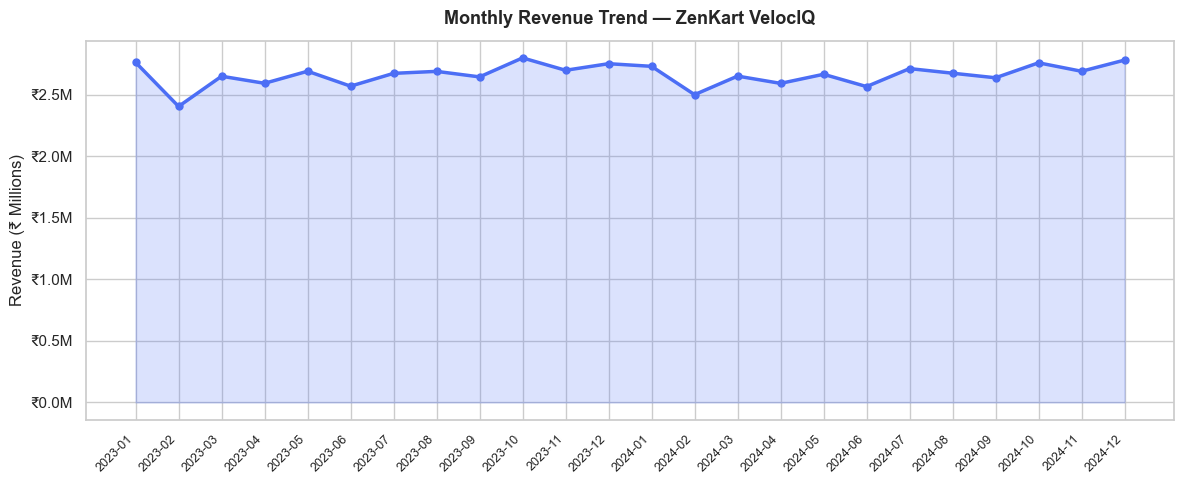

In [58]:
# --- Chart 1: Monthly Revenue Trend ---

monthly = df.groupby(["year","month"])["final_revenue_inr"].sum().reset_index()
monthly["period"] = monthly["year"].astype(str) + "-" + monthly["month"].astype(str).str.zfill(2)
monthly = monthly.sort_values("period")
 
fig, ax = plt.subplots(figsize=(12,5))
ax.fill_between(range(len(monthly)), monthly["final_revenue_inr"]/1e6, alpha=0.2, color="#4C6EF5")
ax.plot(range(len(monthly)), monthly["final_revenue_inr"]/1e6, color="#4C6EF5", linewidth=2.5, marker="o", markersize=5)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly["period"], rotation=45, ha="right", fontsize=9)
ax.set_title("Monthly Revenue Trend — ZenKart VelocIQ", **TITLE_FONT)
ax.set_ylabel("Revenue (₹ Millions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("₹%.1fM"))
plt.tight_layout()
plt.savefig("eda_plots/01_monthly_revenue_trend.png", dpi=150, bbox_inches="tight")
print(" \n ✓ Chart 1: Monthly revenue trend\n")
plt.show()

  ✓ Chart 2: AOV by region


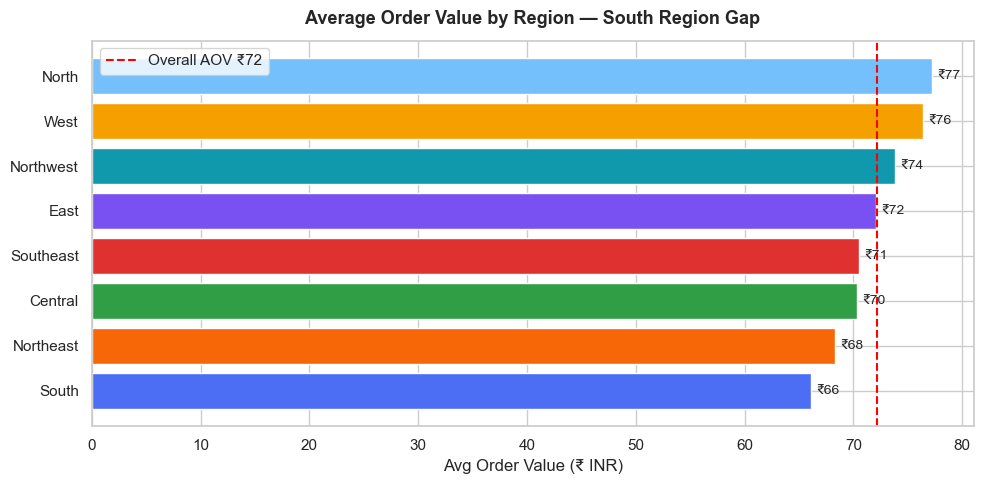

In [52]:
# --- Chart 2: AOV by Region ---
ig, ax = plt.subplots(figsize=(10,5))
region_aov_sorted = df.groupby("region")["final_revenue_inr"].mean().sort_values(ascending=True)
bars = ax.barh(region_aov_sorted.index, region_aov_sorted.values, color=colors[:len(region_aov_sorted)])
ax.axvline(aov_overall, color="red", linestyle="--", linewidth=1.5, label=f"Overall AOV ₹{aov_overall:.0f}")
for bar, val in zip(bars, region_aov_sorted.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2, f"₹{val:.0f}", va="center", fontsize=10)
ax.set_title("Average Order Value by Region — South Region Gap", **TITLE_FONT)
ax.set_xlabel("Avg Order Value (₹ INR)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_plots/02_aov_by_region.png", dpi=150, bbox_inches="tight")
print("  ✓ Chart 2: AOV by region")
plt.show()

  ✓ Chart 3: Cart abandonment by device


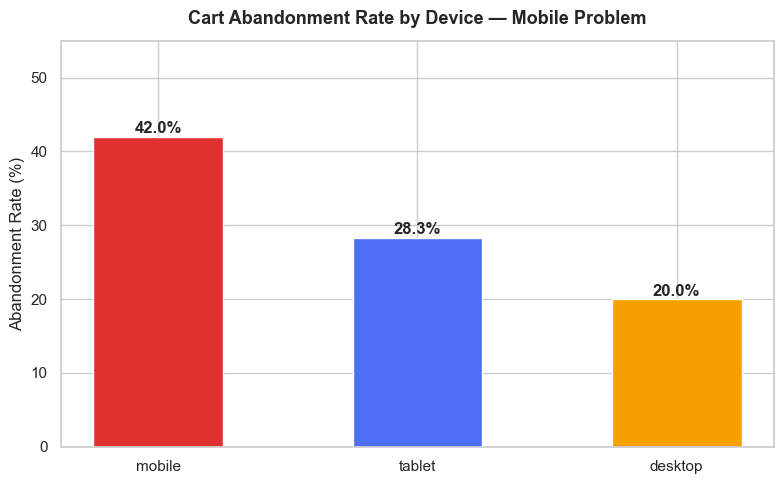

In [53]:
# --- Chart 3: Cart Abandonment by Device ---

ig, ax = plt.subplots(figsize=(8,5))
dev_ab = df.groupby("device_type")["cart_abandon_flag"].mean().sort_values(ascending=False) * 100
bars = ax.bar(dev_ab.index, dev_ab.values, color=["#E03131","#4C6EF5","#F59F00"], width=0.5)
for bar, val in zip(bars, dev_ab.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, f"{val:.1f}%", ha="center", fontsize=12, fontweight="bold")
ax.set_title("Cart Abandonment Rate by Device — Mobile Problem", **TITLE_FONT)
ax.set_ylabel("Abandonment Rate (%)")
ax.set_ylim(0, 55)
plt.tight_layout()
plt.savefig("eda_plots/03_cart_abandon_by_device.png", dpi=150, bbox_inches="tight")
print("  ✓ Chart 3: Cart abandonment by device")
plt.show()

  ✓ Chart 4: Revenue by category


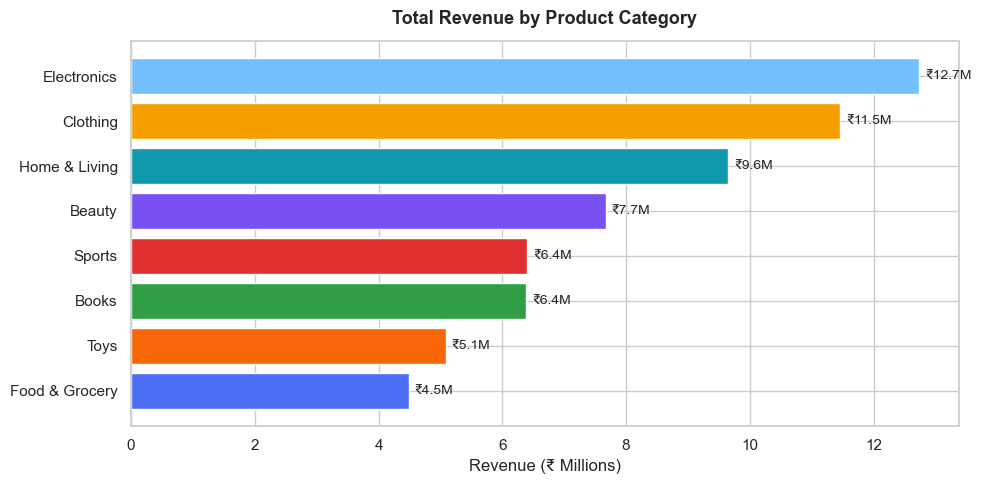

In [59]:
# --- Chart 4: Revenue by Category ---

fig, ax = plt.subplots(figsize=(10,5))
cat_rev = df.groupby("product_category")["final_revenue_inr"].sum().sort_values(ascending=True) / 1e6
bars = ax.barh(cat_rev.index, cat_rev.values, color=colors[:len(cat_rev)])
for bar, val in zip(bars, cat_rev.values):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2, f"₹{val:.1f}M", va="center", fontsize=10)
ax.set_title("Total Revenue by Product Category", **TITLE_FONT)
ax.set_xlabel("Revenue (₹ Millions)")
plt.tight_layout()
plt.savefig("eda_plots/04_revenue_by_category.png", dpi=150, bbox_inches="tight")
print("  ✓ Chart 4: Revenue by category")
plt.show()

  ✓ Chart 5: Revenue distribution


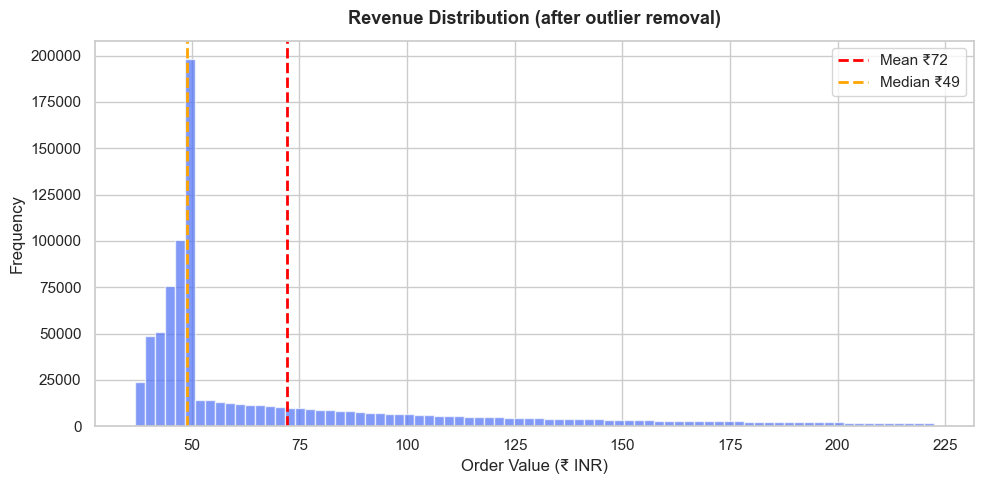

In [61]:
# --- Chart 5: Revenue Distribution ---
fig, ax = plt.subplots(figsize=(10,5))
ax.hist(df["final_revenue_inr"], bins=80, color="#4C6EF5", alpha=0.7, edgecolor="white")
ax.axvline(aov_overall, color="red", linestyle="--", linewidth=2, label=f"Mean ₹{aov_overall:.0f}")
ax.axvline(df["final_revenue_inr"].median(), color="orange", linestyle="--", linewidth=2, label=f"Median ₹{df['final_revenue_inr'].median():.0f}")
ax.set_title("Revenue Distribution (after outlier removal)", **TITLE_FONT)
ax.set_xlabel("Order Value (₹ INR)")
ax.set_ylabel("Frequency")
ax.legend()
plt.tight_layout()
plt.savefig("eda_plots/05_revenue_distribution.png", dpi=150, bbox_inches="tight")
print("  ✓ Chart 5: Revenue distribution")
plt.show()

  ✓ Chart 6: RFM segment distribution


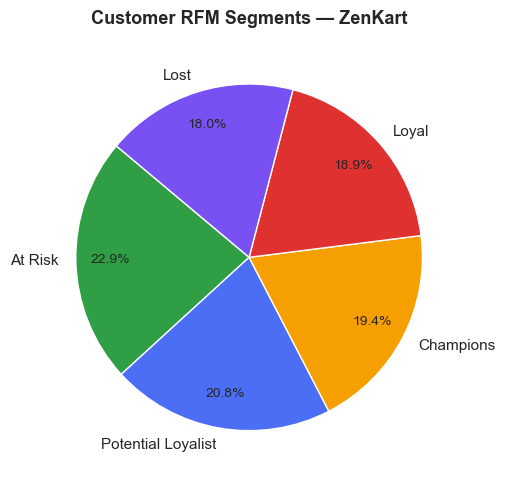

In [62]:
# --- Chart 6: RFM Segment Distribution ---
fig, ax = plt.subplots(figsize=(10,5))
seg_counts = rfm["segment"].value_counts()
wedge_colors = ["#2F9E44","#4C6EF5","#F59F00","#E03131","#7950F2"]
wedges, texts, autotexts = ax.pie(
    seg_counts.values, labels=seg_counts.index,
    autopct="%1.1f%%", colors=wedge_colors,
    startangle=140, pctdistance=0.8
)
for t in autotexts: t.set_fontsize(10)
ax.set_title("Customer RFM Segments — ZenKart", **TITLE_FONT)
plt.tight_layout()
plt.savefig("eda_plots/06_rfm_segments.png", dpi=150, bbox_inches="tight")
print("  ✓ Chart 6: RFM segment distribution")
plt.show()

In [63]:
# --- Chart 7: Discount vs Revenue ---
fig, ax = plt.subplots(figsize=(10,5))
disc_rev = df.groupby("discount_pct")["final_revenue_inr"].agg(["mean","count"]).reset_index()
ax2 = ax.twinx()
ax.bar(disc_rev["discount_pct"].astype(str), disc_rev["mean"], color="#4C6EF5", alpha=0.7, label="Avg Revenue")
ax2.plot(disc_rev["discount_pct"].astype(str), disc_rev["count"], color="#E03131", marker="o", linewidth=2, label="Order Count")
ax.set_title("Discount % vs Avg Revenue & Order Volume", **TITLE_FONT)
ax.set_xlabel("Discount %")
ax.set_ylabel("Avg Order Value (₹)", color="#4C6EF5")
ax2.set_ylabel("Order Count", color="#E03131")
ax.legend(loc="upper left")
ax2.legend(loc="upper right")
plt.tight_layout()
plt.savefig("eda_plots/07_discount_vs_revenue.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✓ Chart 7: Discount vs revenue")

  ✓ Chart 7: Discount vs revenue


In [64]:
# --- Chart 8: Correlation Heatmap ---
fig, ax = plt.subplots(figsize=(10,7))
num_cols = ["final_revenue_inr","quantity","session_duration_mins","discount_pct",
            "cart_abandon_flag","return_flag","is_weekend","is_festive","high_discount"]
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5, annot_kws={"size":9})
ax.set_title("Feature Correlation Heatmap — Project VelocIQ", **TITLE_FONT)
plt.tight_layout()
plt.savefig("eda_plots/08_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.close()
print("  ✓ Chart 8: Correlation heatmap")

  ✓ Chart 8: Correlation heatmap


# PHASE 7 — EXPORT CLEAN FILES

In [65]:
print("\n[PHASE 7] Exporting clean files...")
df.to_csv("zenkart_velociq_clean.csv", index=False)
rfm.to_csv("zenkart_velociq_rfm.csv", index=False)
print(f"  ✓ zenkart_velociq_clean.csv  — {len(df):,} rows, {len(df.columns)} columns")
print(f"  ✓ zenkart_velociq_rfm.csv   — {len(rfm):,} unique customers")
 
print("\n" + "="*60)
print("  EDA COMPLETE — ALL OUTPUTS SAVED")
print("  Charts  : eda_plots/ (8 PNG files)")
print("  Clean   : zenkart_velociq_clean.csv")
print("  RFM     : zenkart_velociq_rfm.csv")
print("="*60)


[PHASE 7] Exporting clean files...
  ✓ zenkart_velociq_clean.csv  — 884,708 rows, 31 columns
  ✓ zenkart_velociq_rfm.csv   — 299,901 unique customers

  EDA COMPLETE — ALL OUTPUTS SAVED
  Charts  : eda_plots/ (8 PNG files)
  Clean   : zenkart_velociq_clean.csv
  RFM     : zenkart_velociq_rfm.csv
